In [1]:
import torch
import torch.nn as nn

# Simple neural network, 1 - 10 - 1: t -> u(t)
model = nn.Sequential(
    nn.Linear(1, 10),
    nn.Tanh(),
    nn.Linear(10, 1)
)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# 20 collocation points, 0 <= t <= 3
t = torch.linspace(0, 3, 20).reshape(-1, 1)
t.requires_grad_(True)

for epoch in range(2000):

    # Network prediction
    u = model(t)

    # du/dt
    u_t = torch.autograd.grad(
        u, t, torch.ones_like(u),
        create_graph=True
    )[0]

    # Physics loss: du/dt + u = 0
    loss_physics = torch.mean((u_t + u)**2)

    # Initial condition: u(0) = 1
    t0 = torch.zeros(1, 1)
    u0 = model(t0)
    loss_initial = (u0 - 1.0)**2

    # Total loss
    loss = loss_physics + loss_initial

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# Compare PINN with exact solution
t_test = torch.linspace(0, 3, 100).reshape(-1, 1)

with torch.no_grad():
    u_pinn = model(t_test)
    u_exact = torch.exp(-t_test)

print(torch.cat((t_test[::10],
                 u_pinn[::10],
                 u_exact[::10]), dim=1))

tensor([[0.0000, 1.0000, 1.0000],
        [0.3030, 0.7374, 0.7386],
        [0.6061, 0.5456, 0.5455],
        [0.9091, 0.4024, 0.4029],
        [1.2121, 0.2968, 0.2976],
        [1.5152, 0.2196, 0.2198],
        [1.8182, 0.1627, 0.1623],
        [2.1212, 0.1201, 0.1199],
        [2.4242, 0.0883, 0.0885],
        [2.7273, 0.0649, 0.0654]])


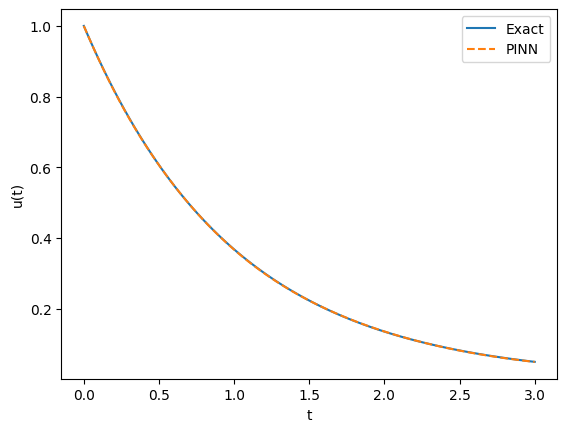

In [2]:
import matplotlib.pyplot as plt

plt.plot(t_test, u_exact, label="Exact")
plt.plot(t_test, u_pinn, "--", label="PINN")
plt.xlabel("t")
plt.ylabel("u(t)")
plt.legend()
plt.show()